In [295]:
import taichi as ti
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import inspect

sp.init_printing("mathjax")

# Solving for angular acceleration

In [296]:
rcm, m, I, g, t = sp.symbols("r_{cm} m I g t")

theta = sp.Function("\\theta")(t)
theta_d = sp.diff(theta, t)

In [297]:
T = sp.Rational(1, 2) * I * theta_d**2
V = -m*g*rcm*sp.cos(theta)
L = T - V

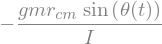

In [298]:
eq_motion = sp.Equality(
    sp.diff(L, theta),
    sp.diff(
        sp.diff(L, theta_d),
        t
    )
)

acc = sp.solve(eq_motion, sp.diff(theta_d, t))[0]
acc_func = sp.lambdify((I, rcm, m, g, theta, theta_d), acc)

acc

# RK4 Simulation

In [299]:
rcm_sim = 1
g_sim = 9.81
I_sim = 1
m_sim = 1

y = np.array([np.pi - 0.001, 1])

def f(y, t):
    return np.array([
        y[1],
        acc_func(I_sim, rcm_sim, m_sim, g_sim, y[0], y[1])
    ])

h = 0.01
t = 0

In [300]:
past_positions = np.array(y)

for i in range(1000):
    k1 = h*f(y, t)
    k2 = h*f(y + k1/2, t + h/2)
    k3 = h*f(y + k2/2, t + h/2)
    k4 = h*f(y + k3, t + h)

    y = y + k1/6 + k2/3 + k3/3 + k4/6

    past_positions = np.vstack([past_positions, y])

Getting the position of the end of the arm. Note: I'm now assuming the arm is a solid bar.

In [301]:
theta_sim = past_positions[:, 0]

x_sim = 2*rcm_sim*np.sin(theta_sim)
y_sim = -2*rcm_sim*np.cos(theta_sim)

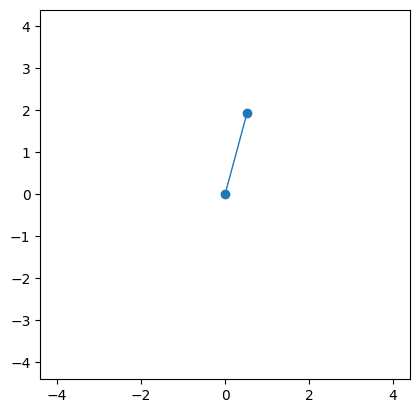

In [302]:
fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.set_xlim(-2.2*2*rcm_sim, 2.2*2*rcm_sim)
ax.set_ylim(-2.2*2*rcm_sim, 2.2*2*rcm_sim)

line, = ax.plot([], [], "o-", lw=1)

def init():
    line.set_data([], [])
    return line,

def update(i):
    this_x = [0, x_sim[i]]
    this_y = [0, y_sim[i]]

    line.set_data(this_x, this_y)
    return line,

ani = FuncAnimation(fig, update, frames=len(theta_sim), init_func=init, blit=True, interval=10)

ani.save("test_single.mp4")